# Estimating Proportions

#### The Euro Problem

A statistical statement from the guardian in 2002:

When spun on edge 250 times, a Belgian one-euro coin came up heads 140 times and tails 110. "It looks very suspicious to me," said Barry Blight, a statistics lecturer at the London School of Economics. "If the coin were unbiased, the change of getting a result as extreme as that would be les than 7%."

But, do the data give evidence that the coin is biased rather than fair?

#### Binomial distribution formula
Suppose the probablility of heads is 'p' and we spin the coin 'n' times. The probability that we get a total of 'k' heads is given by the binomial distribution:

$$\binom{n}{k}p^k(1-p)^{n-k}$$

- n — the total number of trials (coin flips or Bernoulli trials)
- k — the number of "successes" (heads if you want heads)
- p — the probability of success on a single trial
- (1 − p) — the probability of failure on a single trial
- p^k — the probability of getting exactly k successes in a row
- (1 − p)^(n − k) — the probability of getting the remaining (n − k) trials as failures
- (n choose k), aka n!/(k!(n−k)!) — binomial coefficient, the number of different ways to arrange k successes among n trials (the binomial coefficient), since the successes could occur in any order

In [5]:
# flip coin 2 times, heads prob is .5, sucesses is 1, let's find prob
from scipy.stats import binom

n = 2
p = 0.5
k = 1

binom.pmf(k, n, p)

np.float64(0.5000000000000002)

In [6]:
# 3 values for k, consider the probability of all possible outcomes
import numpy as np
ks = np.arange(n+1)
ps = binom.pmf(ks,n,p)
ps

array([0.25, 0.5 , 0.25])

In [7]:
# same thing but another format
from empiricaldist import Pmf

pmf_k = Pmf(ps, ks)
pmf_k

,probs
0,0.25
1,0.50
2,0.25


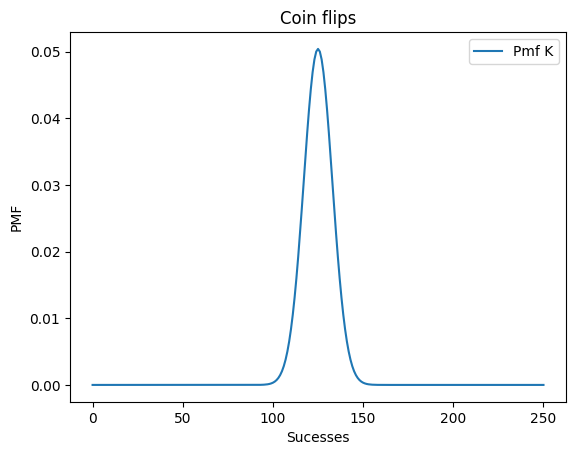

125


In [8]:
def make_binomial(n, p):
    ks = np.arange(n+1)
    ps = binom.pmf(ks, n, p)
    return Pmf(ps, ks)

pmf_k = make_binomial(n = 250, p = 0.5)

import matplotlib.pyplot as plt

pmf_k.plot(label='Pmf K')
plt.xlabel('Sucesses')
plt.ylabel('PMF')
plt.title('Coin flips')
plt.legend()
plt.show()

print(pmf_k.max_prob())

In [9]:
# total probability mass at 125 sucesses
pmf_k[125]

np.float64(0.050412213147309655)

In [10]:
# total probability mass at 140 sucesses 
pmf_k[140]

np.float64(0.008357181724918191)

In [11]:
def prob_ge(pmf, threshold):
    ge = (pmf.qs >= threshold)
    total = pmf[ge].sum()
    return total

print(prob_ge(pmf_k, 140))

#or

print(pmf_k.prob_ge(140))

0.033210575620021665
0.033210575620021665


In [12]:
pmf_k.prob_le(110)

np.float64(0.033210575620021665)

The totals for outcomes 'as extreme' as 140 is 6.6%. 

#### Bayesian Estimation

A balanced 'fair' coin has a probability of landing heads 'x' of about 50%. We can use Bayes's theorem and observed data to estimate x. 

In [13]:
hypos = np.linspace(0,1,101)
prior = Pmf(1, hypos)

likelihood_heads = hypos
likelihood_tails = 1 - hypos

likelihood = {
    'H': likelihood_heads,
    'T': likelihood_tails
}

dataset = 'H' * 140 + 'T' * 110

def update_euro(pmf, dataset):
    for data in dataset:
        pmf*= likelihood[data]

        pmf. normalize()

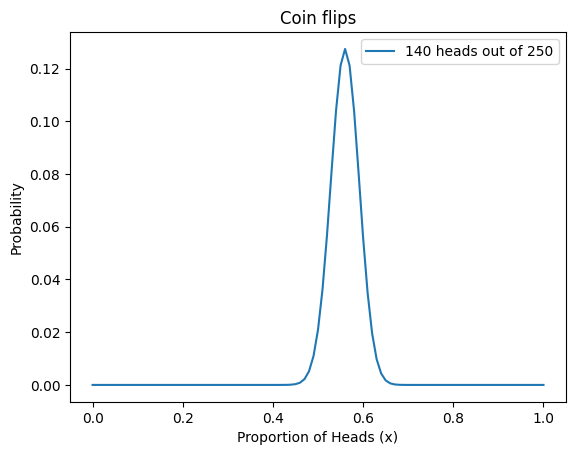

In [14]:
posterior = prior.copy()
update_euro(posterior, dataset)

posterior.plot(label='140 heads out of 250')
plt.xlabel('Proportion of Heads (x)')
plt.ylabel('Probability')
plt.title('Coin flips')
plt.legend()
plt.show()

In [15]:
posterior.max_prob()

np.float64(0.56)

#### Triangle Prior

In [16]:
# We've been using a uniform prior. Let's try a triangle prior. 

ramp_up = np.arange(50)
ramp_down = np.arange(50, -1, -1)

a = np.append(ramp_up, ramp_down)

triangle = Pmf(a, hypos, name = 'triangle')
triangle.normalize()

np.int64(2500)

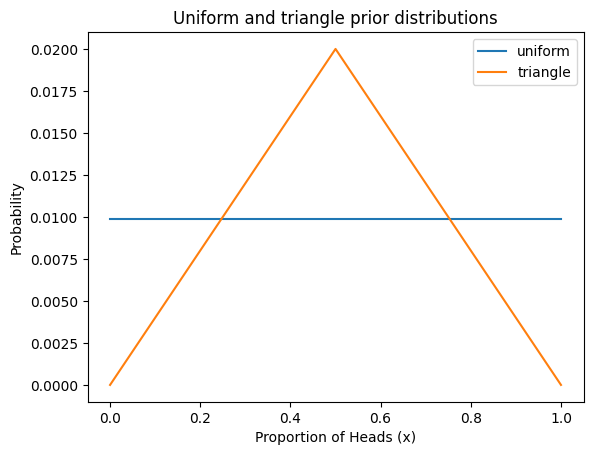

In [17]:
uniform = Pmf(1, hypos, name = 'uniform')
uniform.normalize()

uniform.plot()
triangle.plot()
plt.xlabel('Proportion of Heads (x)')
plt.ylabel('Probability')
plt.title('Uniform and triangle prior distributions')
plt.legend()
plt.show()

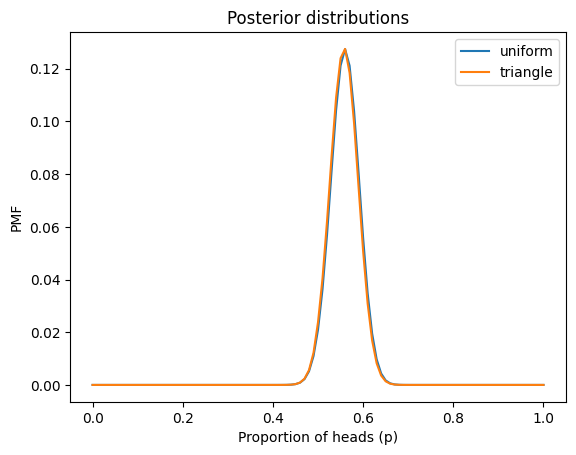

In [18]:
update_euro(uniform, dataset)
update_euro(triangle, dataset)

uniform.plot(label='uniform')
triangle.plot(label='triangle')
plt.xlabel('Proportion of heads (p)')
plt.ylabel('PMF')
plt.title('Posterior distributions')
plt.legend()
plt.show()

#### The Binomial Likelihood Function

In [19]:
from scipy.stats import binom

def update_binomial(pmf, data):
    k, n = data
    xs = pmf.qs
    likelihood = binom.pmf(k,n,xs)
    pmf *= likelihood
    pmf.normalize()

uniform2 = Pmf(1, hypos, name = 'uniform2')
data = 140, 250
update_binomial(uniform2, data)

np.allclose(uniform, uniform2)

True

#### Exercises

In [22]:
#4-1
